<a href="https://colab.research.google.com/github/jtelhu/Data-Science-Project/blob/main/Initial_Project_Presentatiion_108_MAY4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement (Rewrite)

This project analyzes audio features of songs from Multiple Spotify playlists which include:
- "ALL TIME BANGERS – BEST SONGS IN HISTORY" (This Playlist had 206k saves)
- "Top 100 most Streamed Songs" (For general comparison)
- "Compilation of 10,000 Songs by 10000 Artists"
- Top 100 songs from 1970 - 2026 every 5 years to compare the genres and trends as a whole.

to identify common characteristics
associated with highly regarded music selections.

The objective is to examine variables such as danceability, energy, and valence
to determine patterns that may explain why certain songs are perceived as
particularly engaging or “bangers.” I can also play around with genre, record labels, and artists to determine many things

This problem is relevant because music consumption is widespread, and
understanding the measurable attributes of popular songs provides insight
into listener preferences and trends in music production.

## Data Description

The dataset was exported using Exportify from Spotify.
It contains information about songs in a playlist, including artist names,
track names, and audio features such as danceability, energy, and valence.

These features help describe how a song sounds and feels.

This initial presentation is using solely the "ALL TIME BANGERS – BEST SONGS IN HISTORY" playlist for data visualization purposes in the first presentation

In [2]:
# We mount our Google drive folder to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns

#Load the Best Songs in History
SpotifyData = pd.read_csv('/content/drive/My Drive/Colab Notebooks/BEST_SONGS_IN_HISTORY.csv')

In [5]:
from sklearn.linear_model import LinearRegression

## Exploratory Data Analysis

In [ ]:
print("SpotifyData.head():")
display(SpotifyData.head())

SpotifyData.head():


,Track URI,Track Name,Album Name,Artist Name(s),Release Date,Duration (ms),Popularity,Explicit,Added By,Added At,...,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:7iW6diLihH1FMgpK2S0XBD,S&M,Loud,Rihanna,2011-08-18,243532,1,False,6zkdrixrzf4699f8r8klbouu1,2023-03-26T12:51:49Z,...,1,-4.984,1,0.0429,0.0097,0.000140,0.1070,0.818,127.971,4
1,spotify:track:4kLLWz7srcuLKA7Et40PQR,I Gotta Feeling,THE E.N.D. (THE ENERGY NEVER DIES) [Deluxe Ver...,Black Eyed Peas,2009-01-01,289133,86,False,6zkdrixrzf4699f8r8klbouu1,2023-03-26T18:21:38Z,...,0,-6.375,1,0.0265,0.0873,0.000000,0.5090,0.610,127.966,4
2,spotify:track:6ic8OlLUNEATToEFU3xmaH,Gimme More,Blackout,Britney Spears,2007-10-25,251244,87,True,6zkdrixrzf4699f8r8klbouu1,2024-05-24T05:03:47Z,...,2,-3.131,1,0.0334,0.2500,0.000678,0.0723,0.382,113.324,4
3,spotify:track:1QV6tiMFM6fSOKOGLMHYYg,Poker Face,The Fame,Lady Gaga,2008-01-01,237200,86,True,6zkdrixrzf4699f8r8klbouu1,2023-03-26T18:21:55Z,...,4,-4.618,1,0.0787,0.1190,0.000002,0.1210,0.774,119.001,4
4,spotify:track:0gfkjiPutU79nqcPbcR1NR,Copper & Clay,Kinetic Grace,Nona Cyrelle,2026-01-09,261799,44,False,6zkdrixrzf4699f8r8klbouu1,2026-04-13T12:47:21Z,...,4,-9.004,0,0.0348,0.0919,0.000038,0.2270,0.290,113.015,4


In [6]:
print("\nSpotifyData.shape:")
print(SpotifyData.shape)


SpotifyData.shape:
(426, 24)


In [7]:
print("\nSpotifyData.info():")
SpotifyData.info()


SpotifyData.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track URI         426 non-null    object 
 1   Track Name        426 non-null    object 
 2   Album Name        426 non-null    object 
 3   Artist Name(s)    426 non-null    object 
 4   Release Date      426 non-null    object 
 5   Duration (ms)     426 non-null    int64  
 6   Popularity        426 non-null    int64  
 7   Explicit          426 non-null    bool   
 8   Added By          426 non-null    object 
 9   Added At          426 non-null    object 
 10  Genres            202 non-null    object 
 11  Record Label      426 non-null    object 
 12  Danceability      426 non-null    float64
 13  Energy            426 non-null    float64
 14  Key               426 non-null    int64  
 15  Loudness          426 non-null    float64
 16  Mode              426 n

### Subset to just the audio features for analysis

In [8]:
audio_features = ['Danceability','Energy','Valence','Acousticness',
                  'Speechiness','Instrumentalness','Liveness','Loudness','Tempo']
SpotifyAudio = SpotifyData[audio_features]
print("SpotifyAudio.head():")
display(SpotifyAudio.head())

SpotifyAudio.head():


,Danceability,Energy,Valence,Acousticness,Speechiness,Instrumentalness,Liveness,Loudness,Tempo
0,0.762,0.672,0.818,0.0097,0.0429,0.000140,0.1070,-4.984,127.971
1,0.744,0.766,0.610,0.0873,0.0265,0.000000,0.5090,-6.375,127.966
2,0.788,0.844,0.382,0.2500,0.0334,0.000678,0.0723,-3.131,113.324
3,0.851,0.806,0.774,0.1190,0.0787,0.000002,0.1210,-4.618,119.001
4,0.675,0.546,0.290,0.0919,0.0348,0.000038,0.2270,-9.004,113.015


### Graph 1 — Pairplot of audio features:

The pairplot shows the distribution of each feature on the diagonal and pairwise scatterplots off-diagonal. Energy and Loudness skew toward high values, while Acousticness clusters near zero — most tracks in this playlist are produced electronically rather than acoustically. The Energy vs. Loudness panel shows a visible upward trend, which motivates the linear regression in the next section.

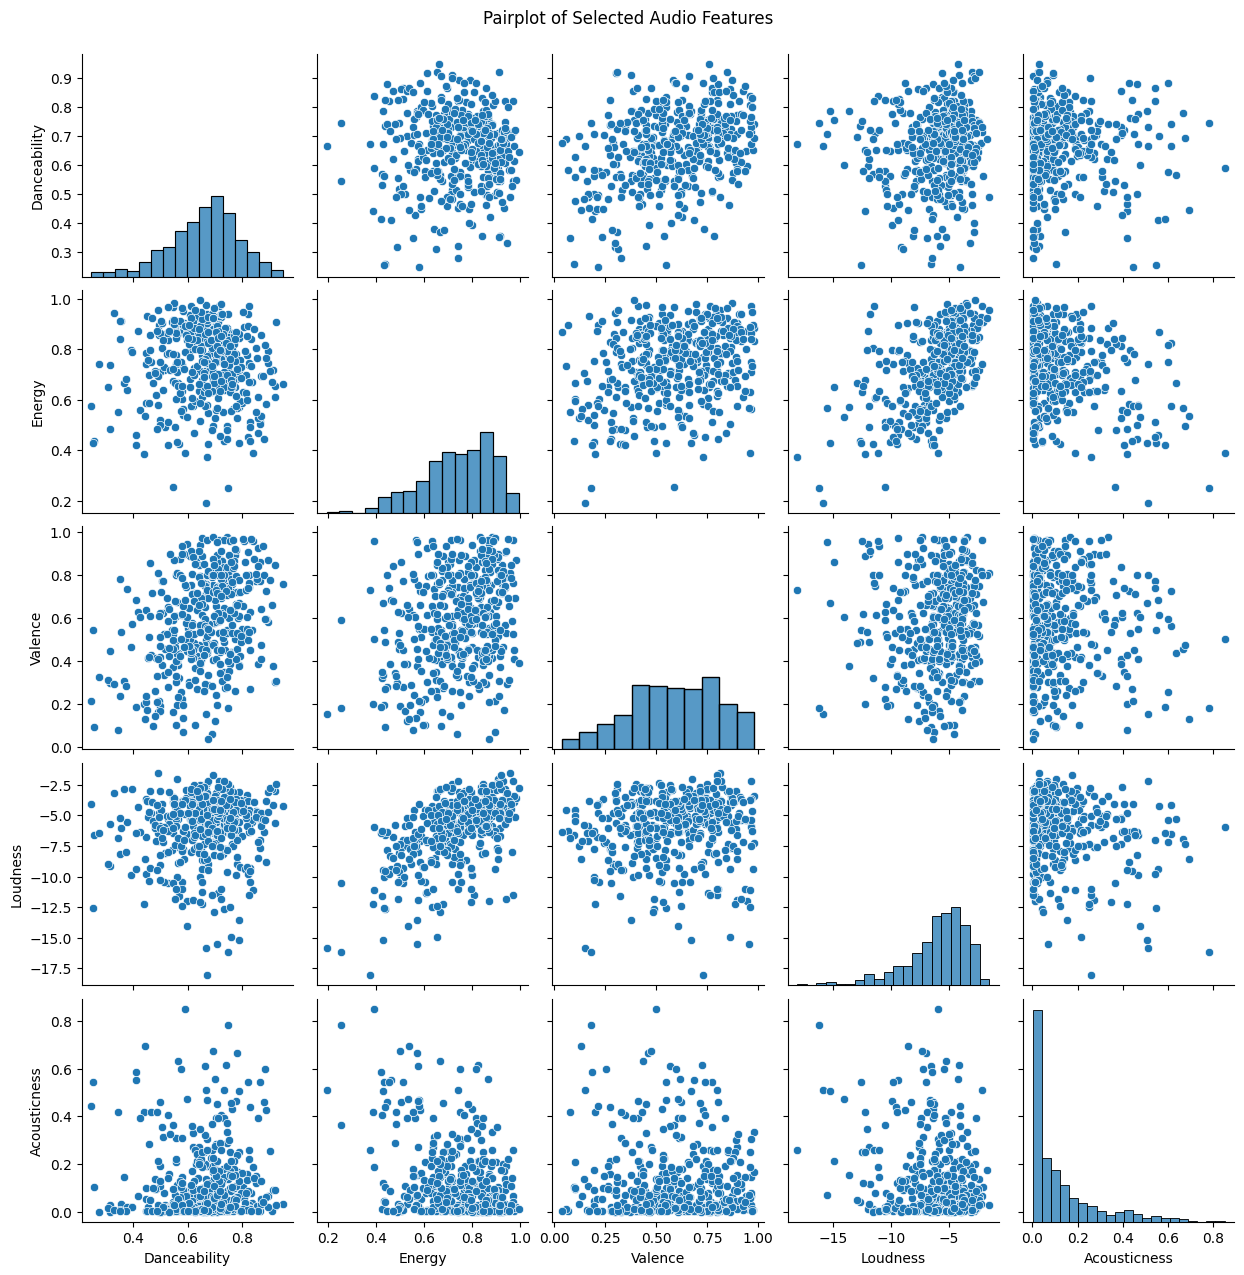

In [ ]:
sns.pairplot(SpotifyAudio[['Danceability','Energy','Valence','Loudness','Acousticness']])
plt.suptitle('Pairplot of Selected Audio Features', y=1.02)
plt.show()

### Graph 2 — Correlation heatmap:
The strongest correlation is between Energy and Loudness (0.59). Energy and Acousticness show a moderate negative correlation (-0.37), which makes sense bc high-energy tracks tend to be electronic rather than acoustic.

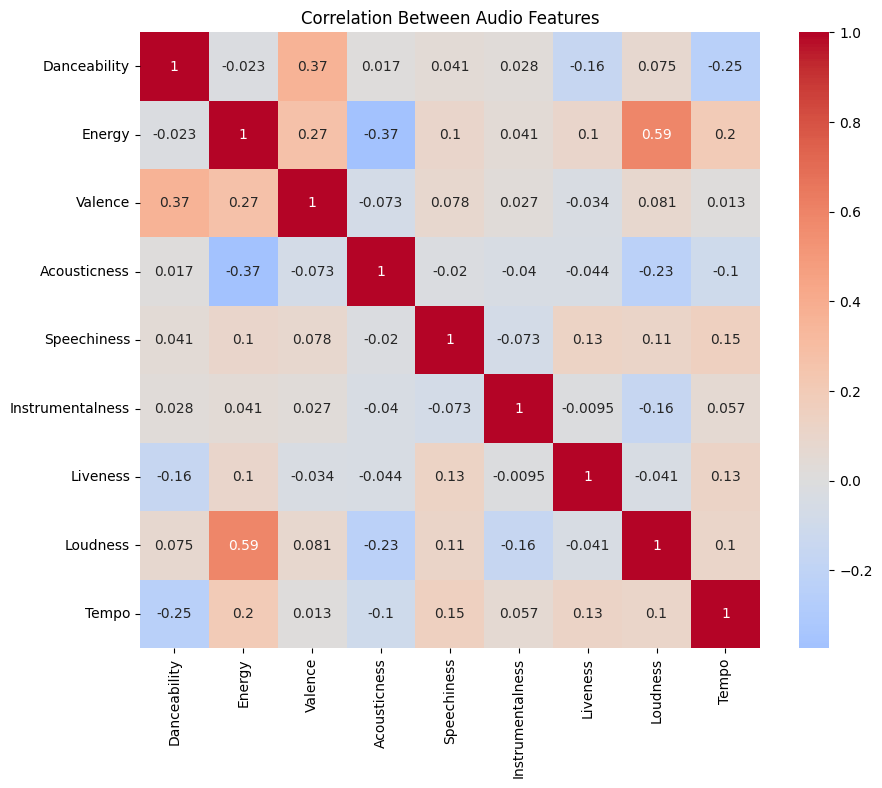

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(SpotifyAudio.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Audio Features')
plt.show()

### Graph 3 — Boxplots to spot outliers:

The boxplots show the spread and outliers for four key features. Danceability and Energy have relatively narrow ranges centered above 0.6, suggesting most tracks in this playlist are upbeat. Valence has the widest spread, meaning the playlist contains a mix of happy and sad-sounding songs. Acousticness is concentrated near zero with many high outliers — confirming that the typical track is electronic, but a handful of acoustic songs exist in the dataset.

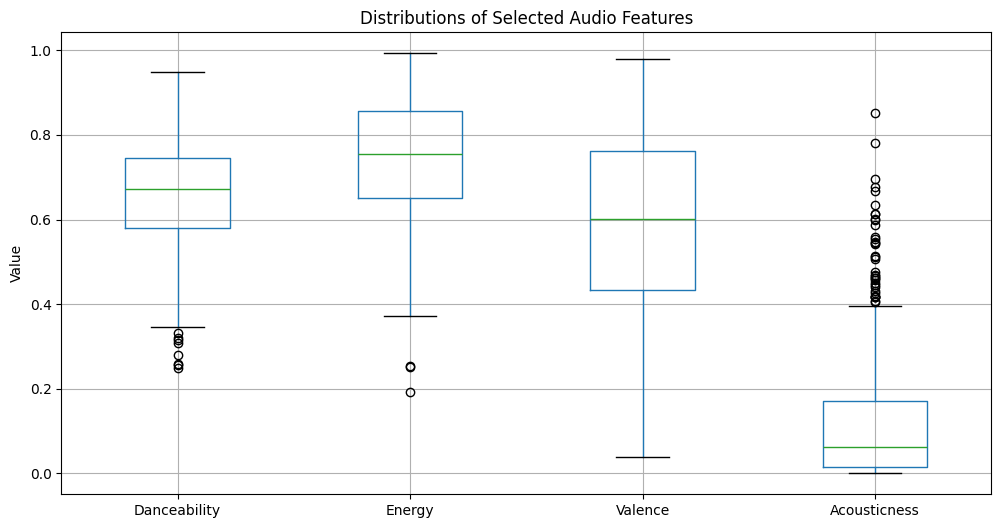

In [ ]:
plt.figure(figsize=(12, 6))
SpotifyAudio[['Danceability','Energy','Valence','Acousticness']].boxplot()
plt.title('Distributions of Selected Audio Features')
plt.ylabel('Value')
plt.show()



### Graph 4 — Missing values check:

- The heatmap confirms that the audio features used in this analysis are complete across all 426 tracks. The only column with substantial missing values is Genres, which is not used in the current analysis. No imputation or row-dropping is needed for the Exploratory Data Analysis and regression work below.

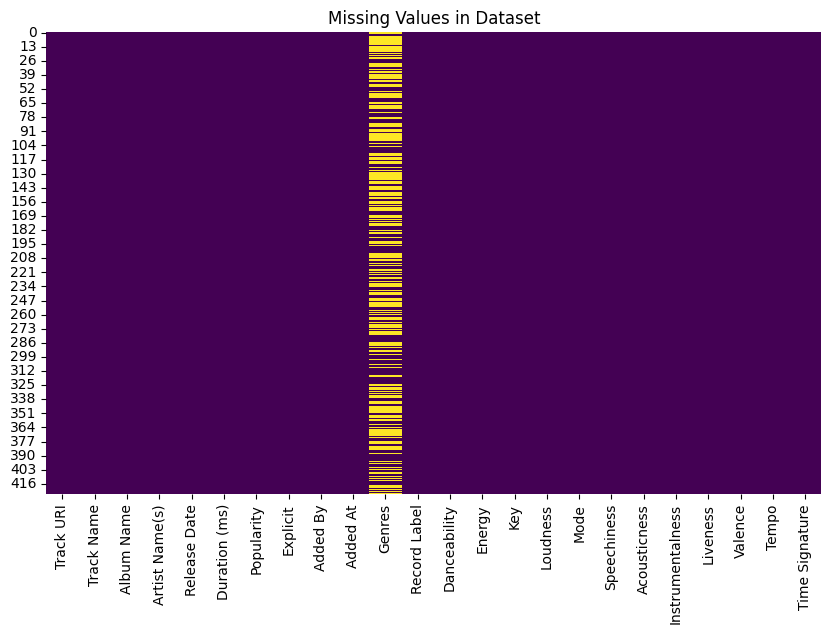

In [10]:
# Missing values check

plt.figure(figsize=(10, 6))
sns.heatmap(SpotifyData.isnull(), cbar=False, cmap='viridis' )
plt.title('Missing Values in Dataset')
plt.show()

## Linear Regression Analysis

Energy → Loudness correlate strongly in Spotify data

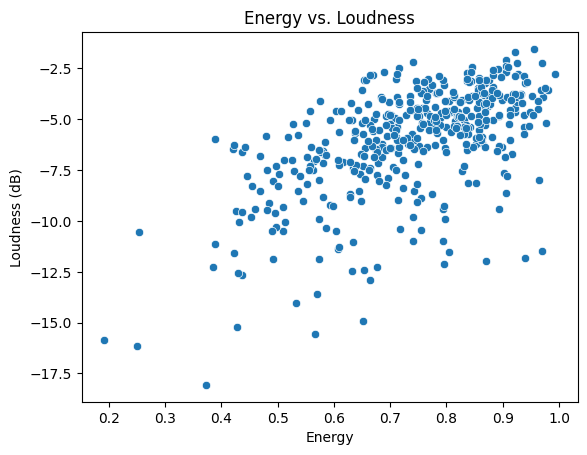

In [ ]:
# Scatter plot
sns.scatterplot(data=SpotifyData, x='Energy', y='Loudness')
plt.xlabel('Energy')
plt.ylabel('Loudness (dB)')
plt.title('Energy vs. Loudness')
plt.show()

In [11]:
# Fit linear regression
linModel = LinearRegression()
linModel.fit(SpotifyData[['Energy']], SpotifyData['Loudness'])
print('Intercept:', linModel.intercept_)
print('Slope:', linModel.coef_)

Intercept: -13.928600005113795
Slope: [10.66677261]


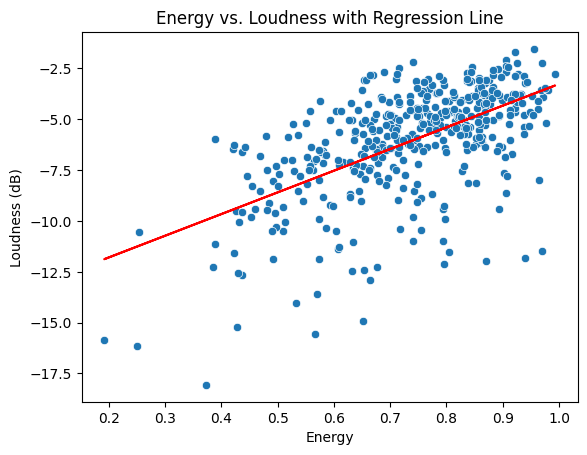

In [12]:
# Plot data + regression line
sns.scatterplot(data=SpotifyData, x='Energy', y='Loudness')
plt.plot(SpotifyData['Energy'], linModel.predict(SpotifyData[['Energy']]), color='red')
plt.xlabel('Energy')
plt.ylabel('Loudness (dB)')
plt.title('Energy vs. Loudness with Regression Line')
plt.show()

The slope of +10.67 means each unit increase in Energy corresponds to about 10.67 dB louder. The correlation of 0.59 confirms this is a real but moderate relationship — about 35% of the variance in loudness is explained by energy.

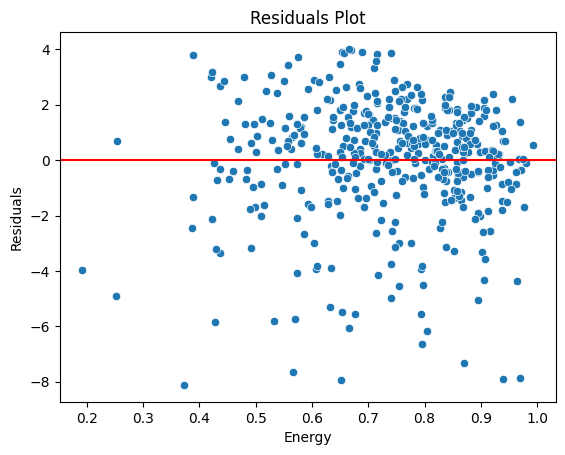

In [13]:
# Residuals plot
ypred = linModel.predict(SpotifyData[['Energy']])
residuals = SpotifyData['Loudness'] - ypred
sns.scatterplot(data=SpotifyData, x='Energy', y=residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Energy')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

In [ ]:
# Correlation coefficient
cMatrix = np.corrcoef(SpotifyData['Energy'], SpotifyData['Loudness'])
print('Correlation coefficient:', cMatrix[0,1])

Correlation coefficient: 0.587732029710636


## Exploratory Visualizations

### Graph 1 — Distribution of Popularity Scores (Histogram)

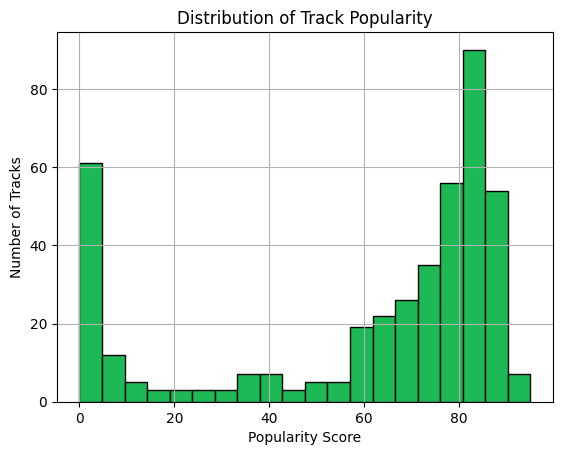

In [15]:
# Graph 1 — popularity distribution
SpotifyData['Popularity'].hist(bins=20, color='#1DB954', edgecolor='black')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.show()

The distribution is bimodal — many tracks score near 0 while another large group scores 70-90. This suggests the playlist mixes still-streaming hits with older tracks that have faded.

### Graph 2 — Bar Chart of Average Audio Features

On average, tracks in this playlist score high on Danceability (0.66), Energy (0.74), and Valence (0.59), and very low on Speechiness, Instrumentalness, and Acousticness. This profile matches the intuition of a "bangers" playlist — energetic, danceable, vocal tracks rather than spoken word, instrumental, or acoustic music. These averages will serve as a baseline to compare against other playlists later in the project.

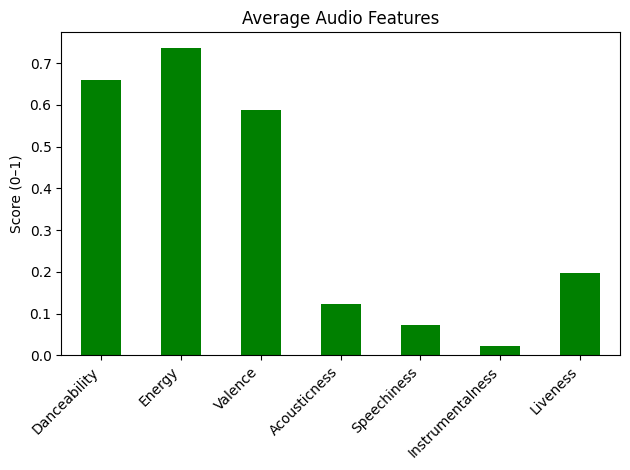

In [14]:
# Graph 2 — average audio features
features = ['Danceability','Energy','Valence','Acousticness','Speechiness','Instrumentalness','Liveness']
SpotifyData[features].mean().plot(kind='bar', color='green')
plt.title('Average Audio Features')
plt.ylabel('Score (0–1)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Graph 3 — Scatter Plot: Danceability vs. Popularity

There is no clear visual relationship between Danceability and Popularity in this playlist. High-popularity tracks span a wide range of danceability scores, and there are popular tracks at almost every danceability level. This suggests that danceability alone does not predict popularity, which motivates the multi-feature analysis planned for future work.

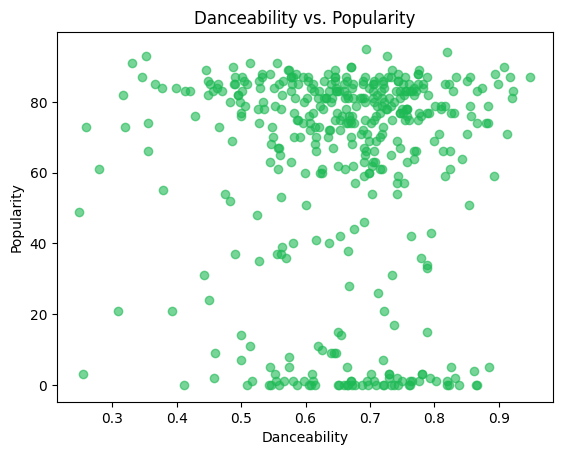

In [16]:
# Graph 3 — danceability vs popularity
plt.scatter(SpotifyData['Danceability'], SpotifyData['Popularity'], alpha=0.6, color='#1DB954')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Danceability vs. Popularity')
plt.show()

## Conclusion
This initial analysis used a 426-track Spotify playlist to test the project pipeline and surface early patterns in the data. Three findings stand out. First, the Popularity distribution is bimodal — the playlist mixes still-streaming hits with older tracks that have faded. Second, the correlation heatmap identifies Energy and Loudness as the strongest pairwise relationship in the dataset (r = 0.59). Third, a simple linear regression confirms that relationship quantitatively, with a slope of +10.67 dB per unit of Energy. Together, these results show that the analysis pipeline works end-to-end and produces interpretable results, setting up the comparison and trend analysis planned for the rest of the project.



# Future Work
Several analyses are planned:

- Statistical tests across popularity groups. Use two-sample t-tests to compare audio features between high-popularity and low-popularity tracks. This will quantify which features differ significantly between the two groups, rather than relying on visual inspection alone.
- Multiple linear regression. Predict the Popularity score from a combination of audio features (Danceability, Energy, Valence, Acousticness) rather than a single feature. The R^2 value will indicate how much of the variation in popularity audio features alone can explain.
- Decade-by-decade comparisons. Combine the playlists from 1970 through 2026 (every five years) and group tracks by release year to chart how the average sound of popular music has shifted over time.
- Cross-playlist comparisons. Compare the "BANGERS" playlist and the top 100 songs from each five-year window (1970–2026) against a merged ~20,000-song reference playlist (combined from multiple 10,000-song collections, with duplicates removed) to see how the audio profile of chart-topping music differs from music in general. The Top 100 Most Streamed Songs playlist will serve as a second comparison group, providing a contrast between historically popular tracks and currently popular tracks.